In [1]:
from transformers import AutoTokenizer
from tnqeet.constants import *

In [2]:
# Dotless characters
RASMS = [
    BAA_RASM,
    FAA_RASM,
    QAF_RASM,
    NOON_RASM,
]
RASMS
# RASMS = ARABIC_RASMS

['ٮ', 'ڡ', 'ٯ', 'ں']

In [3]:
def quick_check(model_id: str):
    """Quick check of a single tokenizer."""
    print(f"\nChecking: {model_id}")
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    tokens = [tokenizer.convert_ids_to_tokens(i) for i in range(tokenizer.vocab_size)]
    vocab = [tokenizer.convert_tokens_to_string([t]).strip() for t in tokens]    
    print(f"\nVocabulary size: {len(vocab):,}\n")
    notfound_rasms = []
    for rasm in RASMS:
        found = False
        for token in vocab:
            if rasm in token:
                found = True
                break
        if not found:
            notfound_rasms.append(rasm)
    found_rasms = set(RASMS) - set(notfound_rasms)
    print(f"Found: {len(found_rasms)}/{len(RASMS)} ({100*len(found_rasms)/len(RASMS):.1f}%)")
    print(f"Missing: {len(notfound_rasms)}/{len(RASMS)}")
    print(f"\n{'='*60}")
    return (len(found_rasms) / len(RASMS)) * 100

In [4]:
models = [
    'meta-llama/Llama-3.2-1B',
    'bigscience/bloom-1b7',
    'Qwen/Qwen2.5-0.5B',
    'CohereLabs/c4ai-command-a-03-2025',
    'google/gemma-3-270m-it',
    
    'aubmindlab/aragpt2-base',
    'core42/jais-13b',
    'humain-ai/ALLaM-7B-Instruct-preview',
    'FreedomIntelligence/AceGPT-7B',
    'silma-ai/SILMA-9B-Instruct-v1.0',
    'CohereLabs/c4ai-command-r7b-arabic-02-2025',
    'CohereLabs/aya-expanse-32b',
    
    
    'aubmindlab/bert-base-arabertv2',
    'CAMeL-Lab/bert-base-arabic-camelbert-msa',
    'UBC-NLP/MARBERT',
    
    'google-bert/bert-base-multilingual-cased',
    'FacebookAI/xlm-roberta-base',
    'microsoft/mdeberta-v3-base',
]

In [5]:
from huggingface_hub import notebook_login
notebook_login()

In [6]:
results = {}

# Your existing code with modification to store results:
for model in models:
    coverage = quick_check(model)  # Your existing function
    if coverage is not None:
        # Extract short name
        short_name = model.split('/')[-1]
        results[short_name] = coverage
results


Checking: meta-llama/Llama-3.2-1B

Vocabulary size: 128,000

Found: 0/4 (0.0%)
Missing: 4/4


Checking: bigscience/bloom-1b7

Vocabulary size: 250,680

Found: 1/4 (25.0%)
Missing: 3/4


Checking: Qwen/Qwen2.5-0.5B

Vocabulary size: 151,643

Found: 2/4 (50.0%)
Missing: 2/4


Checking: CohereLabs/c4ai-command-a-03-2025

Vocabulary size: 255,000

Found: 0/4 (0.0%)
Missing: 4/4


Checking: google/gemma-3-270m-it

Vocabulary size: 262,144

Found: 2/4 (50.0%)
Missing: 2/4


Checking: aubmindlab/aragpt2-base

Vocabulary size: 64,000

Found: 0/4 (0.0%)
Missing: 4/4


Checking: core42/jais-13b

Vocabulary size: 84,992

Found: 0/4 (0.0%)
Missing: 4/4


Checking: humain-ai/ALLaM-7B-Instruct-preview

Vocabulary size: 64,000

Found: 0/4 (0.0%)
Missing: 4/4


Checking: FreedomIntelligence/AceGPT-7B

Vocabulary size: 32,000

Found: 0/4 (0.0%)
Missing: 4/4


Checking: silma-ai/SILMA-9B-Instruct-v1.0

Vocabulary size: 256,000

Found: 3/4 (75.0%)
Missing: 1/4


Checking: CohereLabs/c4ai-command-r7b-ara

/raid_storage/SLURM/home/slurm_majedalshaibani/Projects/tnqeet/.venv/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



Vocabulary size: 250,101

Found: 4/4 (100.0%)
Missing: 0/4



{'Llama-3.2-1B': 0.0,
 'bloom-1b7': 25.0,
 'Qwen2.5-0.5B': 50.0,
 'c4ai-command-a-03-2025': 0.0,
 'gemma-3-270m-it': 50.0,
 'aragpt2-base': 0.0,
 'jais-13b': 0.0,
 'ALLaM-7B-Instruct-preview': 0.0,
 'AceGPT-7B': 0.0,
 'SILMA-9B-Instruct-v1.0': 75.0,
 'c4ai-command-r7b-arabic-02-2025': 0.0,
 'aya-expanse-32b': 0.0,
 'bert-base-arabertv2': 0.0,
 'bert-base-arabic-camelbert-msa': 25.0,
 'MARBERT': 25.0,
 'bert-base-multilingual-cased': 25.0,
 'xlm-roberta-base': 50.0,
 'mdeberta-v3-base': 100.0}

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


def plot_dotless_ratios(model_ratios=results, filename='tnqeet/dotting_models/llms/visualization_figures/llms_rasm_coverage.pdf', models_per_row=3):
    """
    Create publication-ready plot for 2-column paper.
    
    Parameters:
    -----------
    model_ratios : dict
        {model_name: coverage_percentage}
    filename : str
        Output file (use .pdf for papers)
    models_per_row : int
        Models per row in legend (default: 3)
    """
    
    # Colors (colorblind-friendly)
    colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', 
              '#D55E00', '#CC79A7', '#999999', '#8B4513', '#4B0082',
              '#FF1493', '#00CED1', '#FFD700', '#4169E1', '#DC143C']
    
    # Sort by coverage (HIGH TO LOW to match graph left to right)
    items = sorted(model_ratios.items(), key=lambda x: x[1], reverse=True)
    names = [n for n, _ in items]
    ratios = [r for _, r in items]
    n = len(names)
    
    # Assign colors - same coverage = same color
    coverage_to_color = {}  # Map coverage percentage to color
    model_colors = []
    color_index = 0
    
    for ratio in ratios:
        if ratio == 0:
            # All zeros get gray
            model_colors.append('#808080')
        elif ratio in coverage_to_color:
            # Reuse existing color for this coverage percentage
            model_colors.append(coverage_to_color[ratio])
        else:
            # New coverage percentage, assign new color
            color = colors[color_index % len(colors)]
            coverage_to_color[ratio] = color
            model_colors.append(color)
            color_index += 1
    
    # Calculate rows needed for legend
    n_rows = int(np.ceil(n / models_per_row))
    
    # Create figure with proper spacing
    fig, (ax_plot, ax_legend) = plt.subplots(
        2, 1, 
        figsize=(12, 8),
        gridspec_kw={
            'height_ratios': [7, n_rows*0.3],  # Slightly smaller legend
            'hspace': 0.05  # MINIMAL space between plot and legend
        }
    )
    
    # === Plot ===
    x = np.arange(n)
    
    for i, (xi, yi, c) in enumerate(zip(x, ratios, model_colors)):
        # Stem
        ax_plot.plot([xi, xi], [0, yi], color=c, alpha=0.3, linewidth=2)
        # Dot
        ax_plot.scatter(xi, yi, s=120, c=c, alpha=0.85, 
                       edgecolors='black', linewidths=1, zorder=3)
        # Label
        ax_plot.text(xi, yi + 3, f'{yi:.0f}', ha='center', va='bottom', 
                    fontsize=7, fontweight='bold')
    
    # Y-axis
    ax_plot.set_ylim(-5, 105)
    ax_plot.set_ylabel('Coverage (%)', fontsize=9, fontweight='bold')
    ax_plot.set_yticks([0, 25, 50, 75, 100])
    ax_plot.tick_params(axis='y', labelsize=8)
    
    # Hide X-axis
    ax_plot.set_xlim(-0.5, n - 0.5)
    ax_plot.set_xticks([])
    ax_plot.spines['bottom'].set_visible(False)
    ax_plot.spines['top'].set_visible(False)
    ax_plot.spines['right'].set_visible(False)
    
    # Reference lines
    for y in [25, 50, 75, 100]:
        ax_plot.axhline(y, color='gray', linestyle=':', alpha=0.3, linewidth=0.8)
    
    ax_plot.grid(True, axis='y', alpha=0.2, linestyle=':', linewidth=0.5)
    
    # === Legend ===
    ax_legend.axis('off')
    ax_legend.set_xlim(0, 1)
    ax_legend.set_ylim(0, 1)

    # Use fixed spacing - legend width is independent of graph
    col_width = 0.9 / models_per_row
    row_height = 0.85 / n_rows  # Use more of the vertical space
    
    # Start higher to reduce white space at bottom
    y_start = 0.95

    for i, (name, color) in enumerate(zip(names, model_colors)):
        # COLUMN-WISE sorting: fill top-to-bottom in each column
        col = i // n_rows  # Which column
        row = i % n_rows   # Which row within that column
        
        x_pos = 0.05 + col * col_width
        y_pos = y_start - row * row_height
        
        # Use scatter - always circular!
        ax_legend.scatter(x_pos, y_pos, s=100, c=color,  # Slightly larger dots
                        edgecolors='black', linewidths=0.8,
                        transform=ax_legend.transAxes, zorder=3)
        
        # Name - LARGER FONT
        ax_legend.text(x_pos + 0.03, y_pos, name, 
                    transform=ax_legend.transAxes,
                    va='center', ha='left', fontsize=9.5)  # Increased from 7.5
    
    plt.tight_layout()
    
    # Remove extra padding at bottom
    plt.subplots_adjust(bottom=0.05)
    
    plt.savefig(filename, bbox_inches='tight', dpi=300, format='pdf')
    print(f"✓ Saved: {filename}")
    
    return fig

/tmp/ipykernel_3521646/1443342614.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Saved: tnqeet/dotting_models/llms/visualization_figures/llms_rasm_coverage.pdf


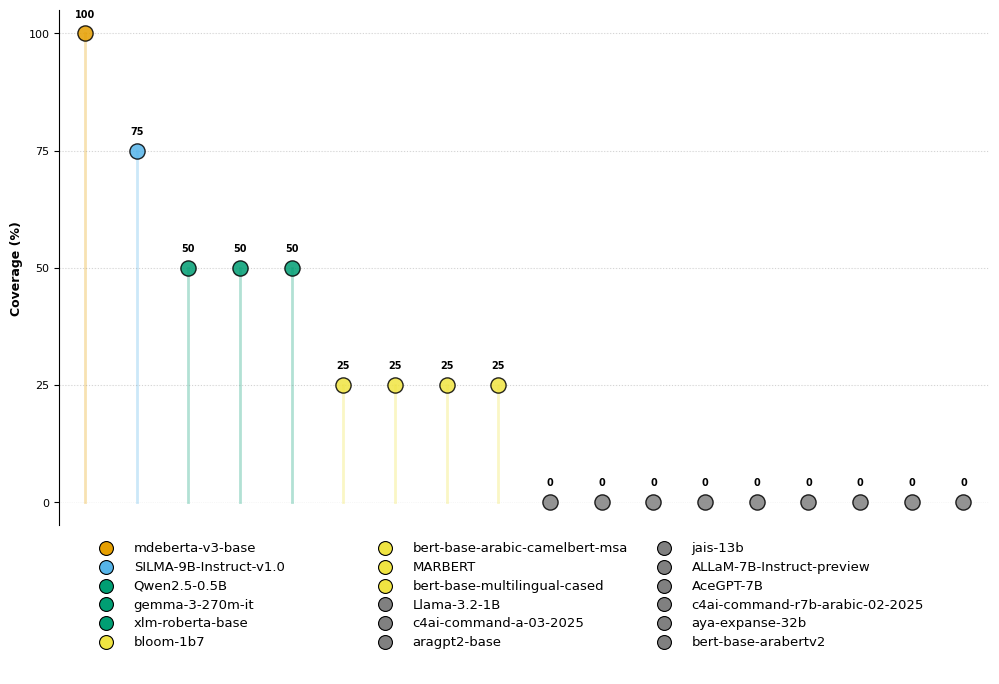

In [8]:
plot_dotless_ratios()
pass